Zadanie 12

Wygeneruj i zinterpretuj learning curves dla dwóch modeli.

Dataset: Digits

Wymagania:
- Decision Tree (max_depth=None) - potencjalny overfitting
- Random Forest (n_estimators=50, max_depth=5) - zbalansowany
- Wykresy obok siebie z interpretacją

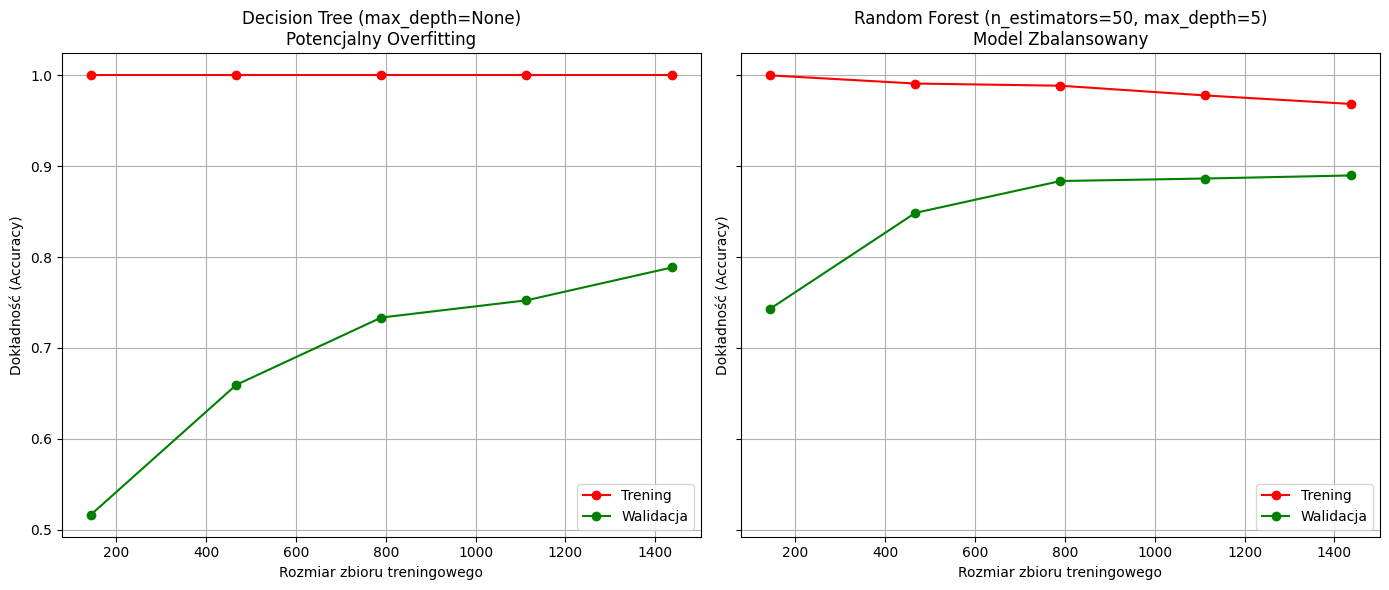

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import learning_curve

# Załadowanie zbioru danych Digits
digits = load_digits()
X, y = digits.data, digits.target

# Inicjalizacja modeli zgodnie z wymaganiami
dt_model = DecisionTreeClassifier(max_depth=None, random_state=42)
rf_model = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

# Definicja rozmiarów zbiorów treningowych (od 10% do 100% danych)
train_sizes = np.linspace(0.1, 1.0, 5)

# Obliczenie krzywych uczenia przy użyciu 5-krotnej walidacji krzyżowej
train_sizes_dt, train_scores_dt, test_scores_dt = learning_curve(
    dt_model, X, y, train_sizes=train_sizes, cv=5, scoring='accuracy', n_jobs=-1
)

train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    rf_model, X, y, train_sizes=train_sizes, cv=5, scoring='accuracy', n_jobs=-1
)

# Obliczenie średnich wyników dla treningu i walidacji
train_mean_dt = np.mean(train_scores_dt, axis=1)
test_mean_dt = np.mean(test_scores_dt, axis=1)
train_mean_rf = np.mean(train_scores_rf, axis=1)
test_mean_rf = np.mean(test_scores_rf, axis=1)

# Wizualizacja

# Przygotowanie wykresów obok siebie
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Wykres dla Drzewa Decyzyjnego
axes[0].plot(train_sizes_dt, train_mean_dt, 'o-', color="r", label="Trening")
axes[0].plot(train_sizes_dt, test_mean_dt, 'o-', color="g", label="Walidacja")
axes[0].set_title("Decision Tree (max_depth=None)\nPotencjalny Overfitting")
axes[0].set_xlabel("Rozmiar zbioru treningowego")
axes[0].set_ylabel("Dokładność (Accuracy)")
axes[0].grid(True)
axes[0].legend(loc="lower right")

# Wykres dla Lasu Losowego
axes[1].plot(train_sizes_rf, train_mean_rf, 'o-', color="r", label="Trening")
axes[1].plot(train_sizes_rf, test_mean_rf, 'o-', color="g", label="Walidacja")
axes[1].set_title("Random Forest (n_estimators=50, max_depth=5)\nModel Zbalansowany")
axes[1].set_xlabel("Rozmiar zbioru treningowego")
axes[1].set_ylabel("Dokładność (Accuracy)")
axes[1].grid(True)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()